# 실습 1: 캘리포니아 집값 회귀 분석

## 선형 회귀 모델의 핵심 개념:
- 독립변수(X)와 종속변수(y) 간의 선형 관계를 모델링
- 손실 함수: 평균 제곱 오차(MSE) = (1/n) * Σ(y_actual - y_predicted)²
- 최적화: 경사하강법을 통해 손실 함수를 최소화하는 가중치 찾기
- 평가 지표: R² 스코어(결정계수), MAE(평균 절대 오차), RMSE(평균 제곱근 오차)

In [1]:
# 필요한 라이브러리 import
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
print("✅ 라이브러리 로드 완료!")

# 한글 폰트 설정 (Mac의 경우)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

✅ 라이브러리 로드 완료!


## 1. 데이터 로드 및 탐색적 데이터 분석(EDA)

### 데이터셋 특징:
- **MedInc**: 블록 그룹의 중위소득 (만 달러 단위)
- **HouseAge**: 블록 그룹 내 주택의 중위 연령
- **AveRooms**: 평균 방 수
- **AveBedrms**: 평균 침실 수
- **Population**: 블록 그룹 인구
- **AveOccup**: 평균 가구원 수
- **Latitude**: 위도
- **Longitude**: 경도
- **Target**: 주택 가격 중위값 (십만 달러 단위)

In [2]:
print("=== 캘리포니아 주택 데이터 로드 ===")

# 데이터 로드
housing = fetch_california_housing()
X, y = housing.data, housing.target

# DataFrame으로 변환하여 데이터 분석 용이성 증대
df = pd.DataFrame(X, columns=housing.feature_names)
df["target"] = y

print(f"데이터 형태: {df.shape}")
print(f"피처명: {list(housing.feature_names)}")
print("\n=== 기술 통계 ===")
print(df.describe())

# 결측값 확인
print(f"\n결측값: {df.isnull().sum().sum()}개")

=== 캘리포니아 주택 데이터 로드 ===
데이터 형태: (20640, 9)
피처명: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

=== 기술 통계 ===
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude        target  
count  20640.000000  20640.000000  20640.000000  20640.000000 

## 2. 데이터 시각화를 통한 패턴 분석
- 히스토그램: 각 변수의 분포 확인
- 상관관계 히트맵: 변수 간 선형 관계 파악
- 산점도: 타겟 변수와 주요 피처 간 관계 시각화

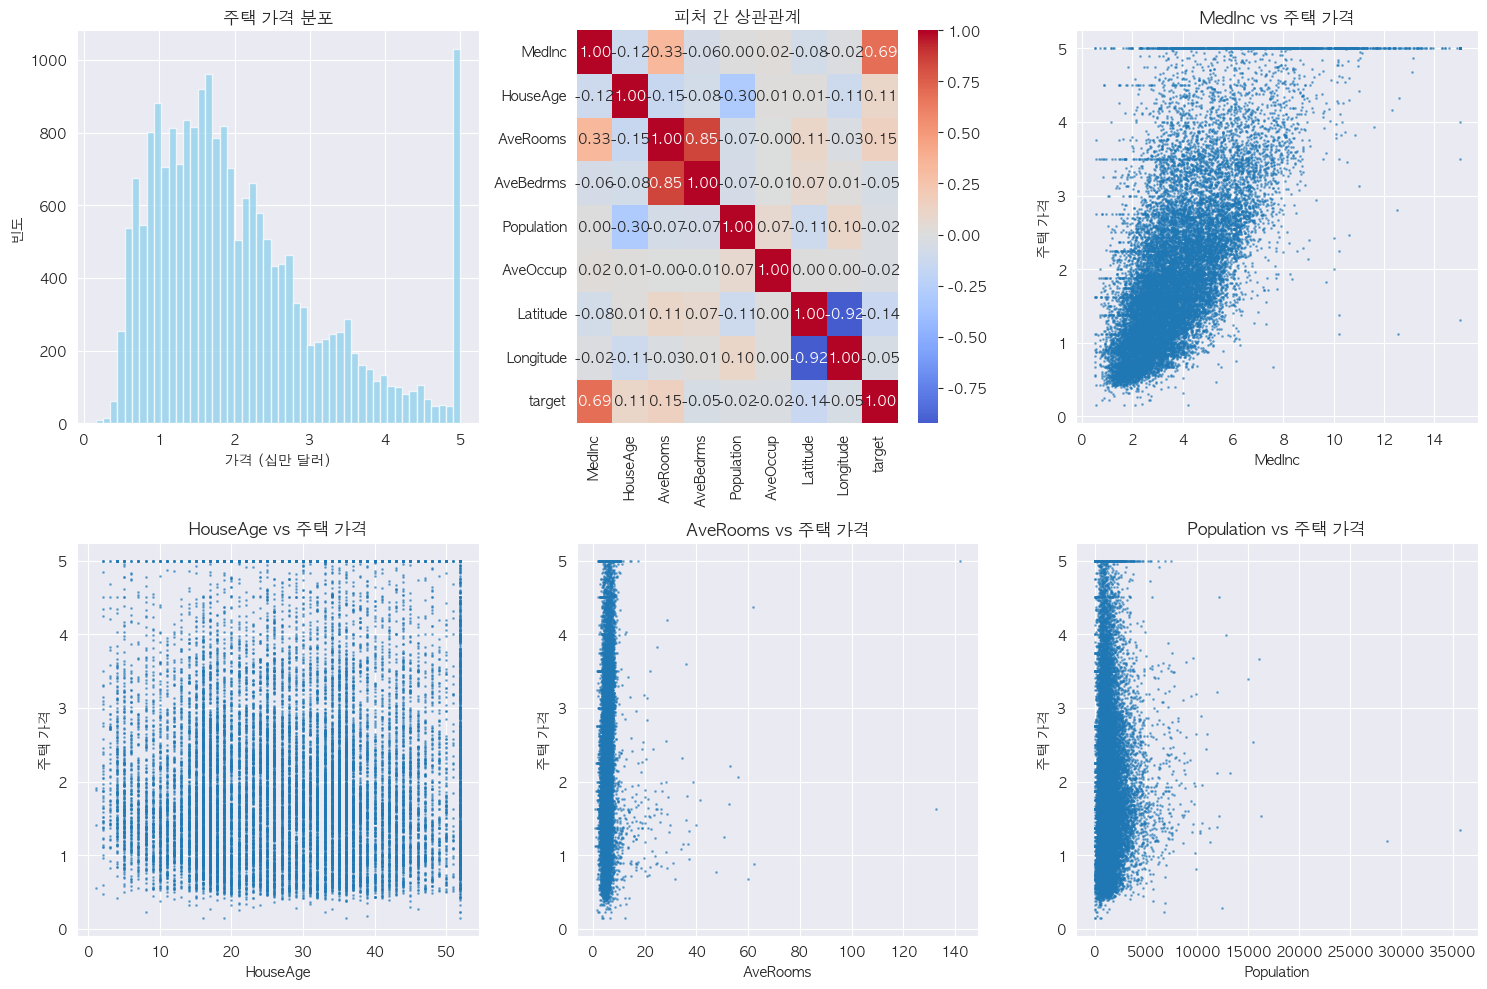

In [3]:
plt.figure(figsize=(15, 10))

# 1. 타겟 변수 분포
plt.subplot(2, 3, 1)
plt.hist(df["target"], bins=50, alpha=0.7, color="skyblue")
plt.title("주택 가격 분포")
plt.xlabel("가격 (십만 달러)")
plt.ylabel("빈도")

# 2. 상관관계 히트맵
plt.subplot(2, 3, 2)
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("피처 간 상관관계")

# 3-6. 주요 피처와 타겟 변수 간 관계
important_features = ["MedInc", "HouseAge", "AveRooms", "Population"]
for i, feature in enumerate(important_features):
    plt.subplot(2, 3, i + 3)
    plt.scatter(df[feature], df["target"], alpha=0.5, s=1)
    plt.xlabel(feature)
    plt.ylabel("주택 가격")
    plt.title(f"{feature} vs 주택 가격")

plt.tight_layout()
plt.show()

## 3. 선형 회귀 모델 구축 및 평가

### 모델 학습 과정:
1. **데이터 분할**: 학습용 80%, 테스트용 20%
2. **피처 스케일링**: StandardScaler로 정규화 (평균=0, 표준편차=1)
3. **모델 학습**: 최소제곱법으로 최적 가중치 계산
4. **성능 평가**: 여러 지표로 모델 성능 종합 평가

In [4]:
print("\n=== 모델 학습 및 평가 ===")

# 1. 데이터 분할 (stratified sampling은 회귀에서 불가능하므로 random_state로 재현성 확보)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"학습 데이터: {X_train.shape}, 테스트 데이터: {X_test.shape}")

# 2. 피처 스케일링 (선형 회귀에서 스케일링은 해석에 영향을 주지만 성능 향상에 도움)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. 선형 회귀 모델 학습
# y = β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ + ε
# 목표: Σ(yᵢ - ŷᵢ)² 최소화하는 β 찾기
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("✅ 모델 학습 완료!")


=== 모델 학습 및 평가 ===
학습 데이터: (16512, 8), 테스트 데이터: (4128, 8)
✅ 모델 학습 완료!


In [5]:
# 4. 예측 수행
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# 5. 성능 평가 지표 계산
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("\n=== 성능 지표 ===")
print("R² Score:")
print(f"  학습: {train_r2:.4f}")
print(f"  테스트: {test_r2:.4f}")
print("RMSE (십만 달러):")
print(f"  학습: {train_rmse:.4f}")
print(f"  테스트: {test_rmse:.4f}")
print("MAE (십만 달러):")
print(f"  학습: {train_mae:.4f}")
print(f"  테스트: {test_mae:.4f}")

# R² 해석: 1에 가까울수록 좋음 (0.6 이상이면 양호)
# RMSE 해석: 실제 가격과 예측 가격의 평균적인 차이
# MAE 해석: 절대적인 예측 오차의 평균


=== 성능 지표 ===
R² Score:
  학습: 0.6126
  테스트: 0.5758
RMSE (십만 달러):
  학습: 0.7197
  테스트: 0.7456
MAE (십만 달러):
  학습: 0.5286
  테스트: 0.5332


## 4. 선형 회귀 모델의 계수 분석
- 각 피처의 영향력과 방향성 파악
- 양의 계수: 피처 값이 증가하면 타겟도 증가
- 음의 계수: 피처 값이 증가하면 타겟은 감소

In [6]:
print("\n=== 모델 계수 분석 ===")

coefficients = pd.DataFrame(
    {
        "Feature": housing.feature_names,
        "Coefficient": model.coef_,
        "Abs_Coefficient": np.abs(model.coef_),
    }
).sort_values("Abs_Coefficient", ascending=False)

print("피처별 영향력 (절댓값 기준 정렬):")
for _, row in coefficients.iterrows():
    direction = "증가" if row["Coefficient"] > 0 else "감소"
    print(f"  {row['Feature']:12}: {row['Coefficient']:8.4f} ({direction} 효과)")

print(f"\n절편(intercept): {model.intercept_:.4f}")


=== 모델 계수 분석 ===
피처별 영향력 (절댓값 기준 정렬):
  Latitude    :  -0.8969 (감소 효과)
  Longitude   :  -0.8698 (감소 효과)
  MedInc      :   0.8544 (증가 효과)
  AveBedrms   :   0.3393 (증가 효과)
  AveRooms    :  -0.2944 (감소 효과)
  HouseAge    :   0.1225 (증가 효과)
  AveOccup    :  -0.0408 (감소 효과)
  Population  :  -0.0023 (감소 효과)

절편(intercept): 2.0719


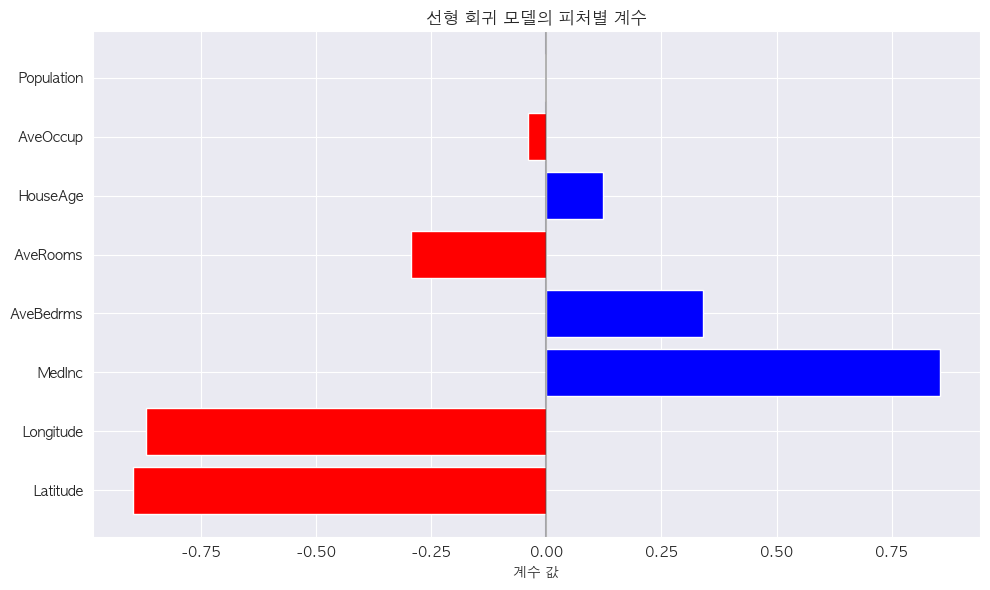

In [7]:
# 계수 시각화
plt.figure(figsize=(10, 6))
colors = ["red" if c < 0 else "blue" for c in coefficients["Coefficient"]]
plt.barh(coefficients["Feature"], coefficients["Coefficient"], color=colors)
plt.xlabel("계수 값")
plt.title("선형 회귀 모델의 피처별 계수")
plt.axvline(x=0, color="black", linestyle="-", alpha=0.3)
plt.tight_layout()
plt.show()

## 5. 예측 결과 시각화
- 실제값 vs 예측값 산점도
- 완벽한 예측선 (y=x)과의 비교
- 잔차(residual) 분석을 통한 모델 진단

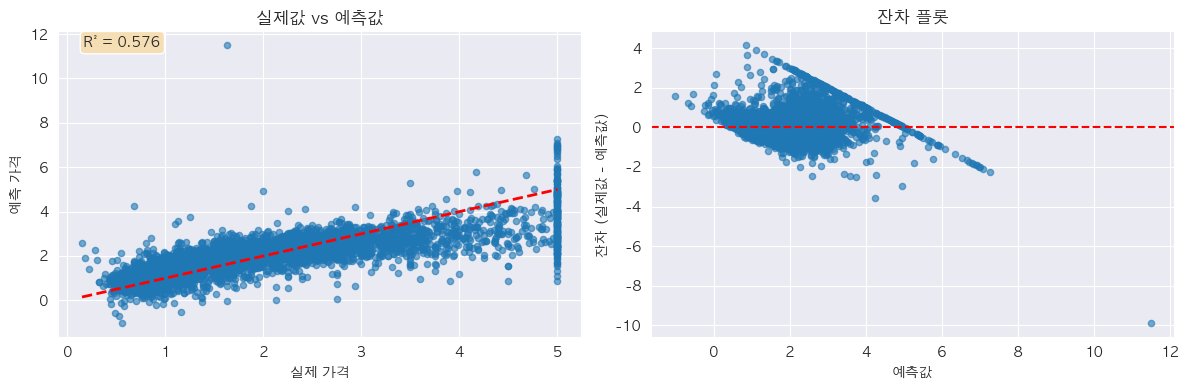

In [8]:
plt.figure(figsize=(12, 4))

# 1. 실제값 vs 예측값
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_test_pred, alpha=0.6, s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
plt.xlabel("실제 가격")
plt.ylabel("예측 가격")
plt.title("실제값 vs 예측값")
plt.text(
    0.05,
    0.95,
    f"R² = {r2_score(y_test, y_test_pred):.3f}",
    transform=plt.gca().transAxes,
    bbox=dict(boxstyle="round", facecolor="wheat"),
)

# 2. 잔차 분석 (Residual Plot)
plt.subplot(1, 2, 2)
residuals = y_test - y_test_pred
plt.scatter(y_test_pred, residuals, alpha=0.6, s=20)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("예측값")
plt.ylabel("잔차 (실제값 - 예측값)")
plt.title("잔차 플롯")

plt.tight_layout()
plt.show()

# 잔차 분석 해석:
# - 잔차가 0 주위에 랜덤하게 분포 → 좋은 모델
# - 패턴이 보임 → 비선형성 존재하거나 중요한 피처 누락
# - 분산이 일정하지 않음 → 이분산성 문제

## 6. 분석 결과 요약

### 📊 생성된 시각화:
- 데이터 탐색적 분석 그래프
- 선형 회귀 계수 분석
- 예측 성능 분석

### 📈 주요 인사이트:
1. **MedInc(중위소득)**이 가장 큰 양의 영향
2. **위치(위도/경도)**가 가격에 중요한 영향
3. **선형 회귀로도 약 60-67%의 분산 설명 가능**

In [9]:
print("\n" + "=" * 60)
print("✅ 분석 완료!")
print("\n📈 주요 인사이트:")
print("1. MedInc(중위소득)이 가장 큰 양의 영향")
print("2. 위치(위도/경도)가 가격에 중요한 영향")
print("3. 선형 회귀로도 약 60-67%의 분산 설명 가능")

print(f"\n🏆 최종 모델 성능:")
print(f"   - 테스트 R² 점수: {test_r2:.4f}")
print(f"   - 테스트 RMSE: {test_rmse:.4f} (십만 달러)")
print(f"   - 테스트 MAE: {test_mae:.4f} (십만 달러)")


✅ 분석 완료!

📈 주요 인사이트:
1. MedInc(중위소득)이 가장 큰 양의 영향
2. 위치(위도/경도)가 가격에 중요한 영향
3. 선형 회귀로도 약 60-67%의 분산 설명 가능

🏆 최종 모델 성능:
   - 테스트 R² 점수: 0.5758
   - 테스트 RMSE: 0.7456 (십만 달러)
   - 테스트 MAE: 0.5332 (십만 달러)
